# Part 2: Exploring Classification Algorithms

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [18]:
data = pd.read_csv('breast-cancer.csv')
data = data.drop(columns=['id'])

# Encode: M=1 (malignant), B=0 (benign)
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

print(f"Shape: {X.shape}")
print(f"Class distribution:\n{y.value_counts()}")
print(f"\nZeros per column:\n{(X == 0).sum().to_string()}")

Shape: (569, 30)
Class distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64

Zeros per column:
radius_mean                 0
texture_mean                0
perimeter_mean              0
area_mean                   0
smoothness_mean             0
compactness_mean            0
concavity_mean             13
concave points_mean        13
symmetry_mean               0
fractal_dimension_mean      0
radius_se                   0
texture_se                  0
perimeter_se                0
area_se                     0
smoothness_se               0
compactness_se              0
concavity_se               13
concave points_se          13
symmetry_se                 0
fractal_dimension_se        0
radius_worst                0
texture_worst               0
perimeter_worst             0
area_worst                  0
smoothness_worst            0
compactness_worst           0
concavity_worst            13
concave points_worst       13
symmetry_worst              0
fractal_dimension_wo

In [19]:
# --- Replace 0's with NaN ---
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']
X = X.replace(0, np.nan)

# print(f"NaN per column:\n{X.isna().sum().to_string()}")


In [20]:

# --- Compare imputation strategies ---
#Mean imputation
X_mean = X.copy()
mean_imputer = SimpleImputer(strategy='mean')
X_mean_imputed = mean_imputer.fit_transform(X_mean) 

#Median imputation
X_median = X.copy()
median_imputer = SimpleImputer(strategy='median')
X_median_imputed = median_imputer.fit_transform(X_median)

# Train/Predict Mean imputation
X_train_mean, X_test_mean, y_train_mean, y_test_mean = train_test_split(X_mean_imputed, y, test_size=0.3, random_state=33)
decision_tree_mean = DecisionTreeClassifier(max_depth=8, random_state=33)
decision_tree_mean.fit(X_train_mean, y_train_mean)
predictions_mean = decision_tree_mean.predict(X_test_mean)

# Evaluate Mean: accuracy, precision, recall, F1
accuracy_mean = accuracy_score(y_test_mean, predictions_mean)
precision_mean = precision_score(y_test_mean, predictions_mean)
recall_mean = recall_score(y_test_mean, predictions_mean)
f1_mean = f1_score(y_test_mean, predictions_mean)


# Train/Predict Mean imputation
X_train_median, X_test_median, y_train_median, y_test_median = train_test_split(X_median_imputed, y, test_size=0.3, random_state=33)
decision_tree_median = DecisionTreeClassifier(max_depth=8, random_state=33)
decision_tree_median.fit(X_train_median, y_train_median)
predictions_median = decision_tree_median.predict(X_test_median)

# Evaluate Median: accuracy, precision, recall, F1
accuracy_median = accuracy_score(y_test_median, predictions_median)
precision_median = precision_score(y_test_median, predictions_median)
recall_median = recall_score(y_test_median, predictions_median)
f1_median = f1_score(y_test_median, predictions_median)


# Print results
print("\n" + "=" * 40)
print("Mean Imputation:")
print(f"Accuracy: {accuracy_mean:.4f}")
print(f"Precision: {precision_mean:.4f}")
print(f"Recall: {recall_mean:.4f}")
print(f"F1 Score: {f1_mean:.4f}\n")
print("-" * 40 + "\n")
print("Median Imputation:")
print(f"Accuracy: {accuracy_median:.4f}")
print(f"Precision: {precision_median:.4f}")
print(f"Recall: {recall_median:.4f}")
print(f"F1 Score: {f1_median:.4f}")
print("\n" + "=" * 40)


if accuracy_mean > accuracy_median:
    print("Mean imputation performed better. Using mean imputation for the rest of the analysis.")
    X_clean = X_mean_imputed
else:
    print("Median imputation performed better. Using median imputation for the rest of the analysis.")
    X_clean = X_median_imputed

X_clean = pd.DataFrame(X_clean, columns=X.columns)


Mean Imputation:
Accuracy: 0.9181
Precision: 0.8611
Recall: 0.9394
F1 Score: 0.8986

----------------------------------------

Median Imputation:
Accuracy: 0.9181
Precision: 0.8611
Recall: 0.9394
F1 Score: 0.8986

Median imputation performed better. Using median imputation for the rest of the analysis.


In [21]:
# Reusable evaluation helper for all steps
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
    }

In [22]:
# Step 3: Normalization comparison — KNN and Decision Tree across 3 scaling methods
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.3, random_state=33)

results = []
for norm_name, scaler in [('None', None), ('MinMax', MinMaxScaler()), ('Standard', StandardScaler())]:
    Xtr = X_train.copy()
    Xte = X_test.copy()
    if scaler:
        Xtr = pd.DataFrame(scaler.fit_transform(Xtr), columns=X_clean.columns)
        Xte = pd.DataFrame(scaler.transform(Xte), columns=X_clean.columns)
    
    for model_name, model in [('KNN', KNeighborsClassifier(n_neighbors=9)), ('DT', DecisionTreeClassifier(max_depth=8, random_state=33))]:
        metrics = evaluate_model(model, Xtr, Xte, y_train, y_test)
        results.append({'Model': model_name, 'Normalization': norm_name, **metrics})

norm_results = pd.DataFrame(results)
print(norm_results.to_string(index=False))

Model Normalization  Accuracy  Precision   Recall       F1
  KNN          None  0.918129   0.933333 0.848485 0.888889
   DT          None  0.918129   0.861111 0.939394 0.898551
  KNN        MinMax  0.964912   0.968750 0.939394 0.953846
   DT        MinMax  0.918129   0.861111 0.939394 0.898551
  KNN      Standard  0.970760   0.984127 0.939394 0.961240
   DT      Standard  0.918129   0.861111 0.939394 0.898551


In [23]:
# Set Train/Test split for Question 2 

X_train_std, X_test_std, y_train_std, y_test_std = train_test_split(X_clean, y, test_size=0.3, random_state=33)
scaler = StandardScaler()
X_train_std = pd.DataFrame(scaler.fit_transform(X_train_std), columns=X_clean.columns)
X_test_std = pd.DataFrame(scaler.transform(X_test_std), columns=X_clean.columns)


In [24]:
# Train KNN with different Hyperparameters using the standardised data
hyperparams =  [3, 9, 15, 21]

for k in hyperparams:
    knn = KNeighborsClassifier(n_neighbors=k)
    metrics = evaluate_model(knn, X_train_std, X_test_std, y_train_std, y_test_std)
    print(f"KNN with k={k}: Accuracy={metrics['Accuracy']:.4f}, Precision={metrics['Precision']:.4f}, Recall={metrics['Recall']:.4f}, F1={metrics['F1']:.4f}")

KNN with k=3: Accuracy=0.9708, Precision=0.9692, Recall=0.9545, F1=0.9618
KNN with k=9: Accuracy=0.9708, Precision=0.9841, Recall=0.9394, F1=0.9612
KNN with k=15: Accuracy=0.9825, Precision=1.0000, Recall=0.9545, F1=0.9767
KNN with k=21: Accuracy=0.9591, Precision=1.0000, Recall=0.8939, F1=0.9440


In [25]:
# Train Decision Tree with different Hyperparameters

hyperparams = [2, 8, 14]

for depth in hyperparams:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=33)
    metrics = evaluate_model(dt, X_train_std, X_test_std, y_train_std, y_test_std)
    print(f"Decision Tree with max_depth={depth}: Accuracy={metrics['Accuracy']:.4f}, Precision={metrics['Precision']:.4f}, Recall={metrics['Recall']:.4f}, F1={metrics['F1']:.4f}")

Decision Tree with max_depth=2: Accuracy=0.8947, Precision=0.8429, Recall=0.8939, F1=0.8676
Decision Tree with max_depth=8: Accuracy=0.9181, Precision=0.8611, Recall=0.9394, F1=0.8986
Decision Tree with max_depth=14: Accuracy=0.9181, Precision=0.8611, Recall=0.9394, F1=0.8986


In [26]:
# Train AdaBoost with different Hyperparameters

hyperparams = [10, 20, 30]
for n_estimators in hyperparams:
    ada = AdaBoostClassifier(n_estimators=n_estimators, random_state=33)
    metrics = evaluate_model(ada, X_train_std, X_test_std, y_train_std, y_test_std)
    print(f"AdaBoost with n_estimators={n_estimators}: Accuracy={metrics['Accuracy']:.4f}, Precision={metrics['Precision']:.4f}, Recall={metrics['Recall']:.4f}, F1={metrics['F1']:.4f}")

AdaBoost with n_estimators=10: Accuracy=0.9474, Precision=0.9014, Recall=0.9697, F1=0.9343
AdaBoost with n_estimators=20: Accuracy=0.9532, Precision=0.9143, Recall=0.9697, F1=0.9412
AdaBoost with n_estimators=30: Accuracy=0.9532, Precision=0.9143, Recall=0.9697, F1=0.9412


In [27]:
# Train Random Forest with different Hyperparameters

hyperparams = [10, 30, 50, 60]
for n_estimators in hyperparams:
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=33)
    metrics = evaluate_model(rf, X_train_std, X_test_std, y_train_std, y_test_std)
    print(f"Random Forest with n_estimators={n_estimators}: Accuracy={metrics['Accuracy']:.4f}, Precision={metrics['Precision']:.4f}, Recall={metrics['Recall']:.4f}, F1={metrics['F1']:.4f}")

Random Forest with n_estimators=10: Accuracy=0.9357, Precision=0.9104, Recall=0.9242, F1=0.9173


Random Forest with n_estimators=30: Accuracy=0.9415, Precision=0.9375, Recall=0.9091, F1=0.9231
Random Forest with n_estimators=50: Accuracy=0.9532, Precision=0.9677, Recall=0.9091, F1=0.9375
Random Forest with n_estimators=60: Accuracy=0.9591, Precision=0.9683, Recall=0.9242, F1=0.9457



Feature Correlations with Target:
concave points_worst       0.794594
perimeter_worst            0.782914
radius_worst               0.776454
concave points_mean        0.773979
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.691300
concavity_worst            0.652831
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.393445
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.241464
fractal_dimension_se       0.077972
smoothness_se              0.

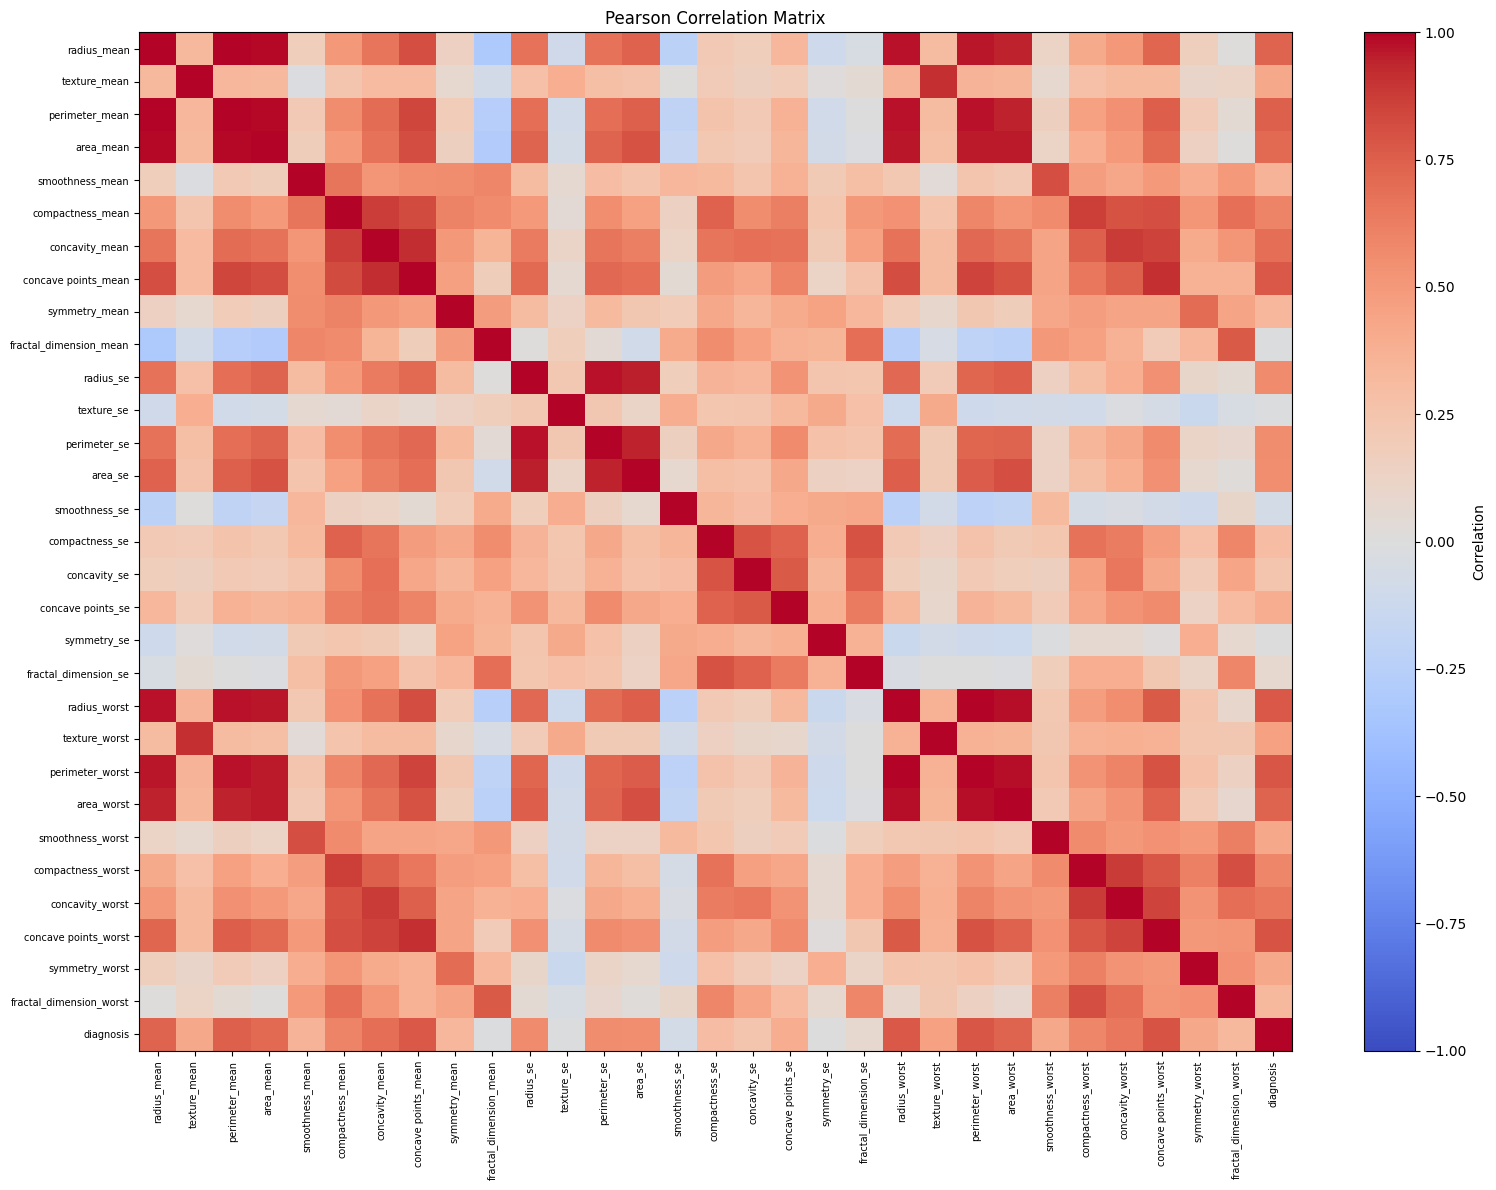

In [28]:
# Feature Selection with Pearson Correlation

correlations = X_clean.corrwith(y)
correlations = correlations.abs().sort_values(ascending=False)
print("\nFeature Correlations with Target:")
print(correlations.to_string())

filtered_features = correlations[correlations > 0.6].index.tolist()
print(f"\nFeatures retained (|corr| > 0.6): {len(filtered_features)}")
print(filtered_features)

# Full correlation matrix (features + target)
full_data = X_clean.copy()
full_data['diagnosis'] = y
corr_matrix = full_data.corr()

# Heatmap
plt.figure(figsize=(16, 12))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns, fontsize=7)
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

In [29]:
# Decision Tree with selected features compared to all features
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(X_clean[filtered_features], y, test_size=0.3, random_state=33)

feature_selection_dt = DecisionTreeClassifier(max_depth=8, random_state=33)
metrics_fs = evaluate_model(feature_selection_dt, X_train_fs, X_test_fs, y_train_fs, y_test_fs)
print(f"\nDecision Tree with selected features: Accuracy={metrics_fs['Accuracy']:.4f}, Precision={metrics_fs['Precision']:.4f}, Recall={metrics_fs['Recall']:.4f}, F1={metrics_fs['F1']:.4f}")

# Decision Tree with all features for comparison
full_decision_tree = DecisionTreeClassifier(max_depth=8, random_state=33)
full_metrics = evaluate_model(full_decision_tree, X_train_std, X_test_std, y_train_std, y_test_std)

comparison = pd.DataFrame([
    {'Features': 'All', **full_metrics},
    {'Features': 'Selected', **metrics_fs},
])
print(comparison.to_string(index=False))


Decision Tree with selected features: Accuracy=0.9064, Precision=0.8472, Recall=0.9242, F1=0.8841
Features  Accuracy  Precision   Recall       F1
     All  0.918129   0.861111 0.939394 0.898551
Selected  0.906433   0.847222 0.924242 0.884058


In [30]:
# Feature Selection with PCA

X_train_split, X_test_split, y_train_pca, y_test_pca = train_test_split(X_clean, y, test_size=0.3, random_state=33)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_split), columns=X_clean.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_split), columns=X_clean.columns)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Components retained: {pca.n_components_}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.4f}")

results = []
for depth in [2, 8]:
    metrics_no_pca = evaluate_model(DecisionTreeClassifier(max_depth=depth, random_state=33), X_train_scaled, X_test_scaled, y_train_pca, y_test_pca)
    metrics_pca = evaluate_model(DecisionTreeClassifier(max_depth=depth, random_state=33), X_train_pca, X_test_pca, y_train_pca, y_test_pca)
    results.append({'Depth': depth, 'PCA': 'No', **metrics_no_pca})
    results.append({'Depth': depth, 'PCA': 'Yes', **metrics_pca})

pd.DataFrame(results)



Components retained: 10
Explained variance: 0.9505


,Depth,PCA,Accuracy,Precision,Recall,F1
0,2,No,0.894737,0.842857,0.893939,0.867647
1,2,Yes,0.888889,0.850746,0.863636,0.857143
2,8,No,0.918129,0.861111,0.939394,0.898551
3,8,Yes,0.935673,0.936508,0.893939,0.914729
